In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
raw_df = pd.read_csv("../data/spotify_tracks.csv")
clustered_df = pd.read_csv("../data/spotify_tracks_clustered_moods.csv")

raw_df["cluster"] = clustered_df["cluster"]
raw_df["mood_name"] = clustered_df["mood_name"]

df = raw_df
print(df.shape)
df.head()

(114000, 23)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,mood_name
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,5,Party Beast
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1,Acoustic Chill
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1,Acoustic Chill
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1,Acoustic Chill
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1,Acoustic Chill


In [18]:
feature_cols = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness", "tempo"
]
# Features for plotting

# ## CLUSTER COUNT BAR CHART

In [19]:
# COUNT SONGS PER CLUSTER 
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_counts

cluster
0    11403
1    22450
2     7405
3    26561
4     7916
5    37124
6     1141
Name: count, dtype: int64

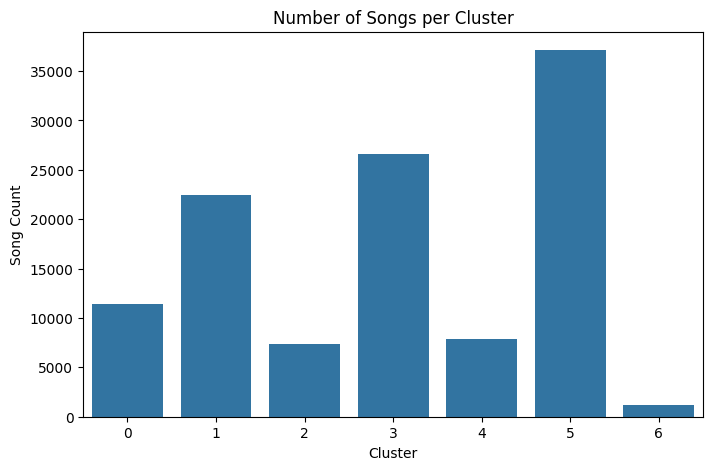

In [20]:
# BAR CHART
plt.figure(figsize=(8,5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Number of Songs per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Song Count")
plt.show()

# ##Average Audio Feature per Cluster

In [21]:
# Average Audio Feature per Cluster
cluster_avg = df.groupby("cluster")[feature_cols].mean()
cluster_avg

,danceability,energy,valence,acousticness,instrumentalness,speechiness,liveness,tempo
cluster,,,,,,,,
0,0.585570,0.757270,0.338454,0.088463,0.786379,0.072118,0.172209,127.702535
1,0.520349,0.372103,0.376548,0.692899,0.020667,0.051409,0.156332,112.314661
2,0.367677,0.189541,0.203960,0.856923,0.843823,0.051172,0.152683,103.762211
3,0.473881,0.807849,0.371552,0.073351,0.031414,0.082771,0.190941,139.723268
4,0.519497,0.748116,0.507470,0.290408,0.070106,0.086623,0.737977,123.289989
5,0.705146,0.716016,0.695650,0.213458,0.019084,0.093560,0.164338,117.854693
6,0.575431,0.669989,0.446394,0.717210,0.010766,0.821571,0.636953,102.057166


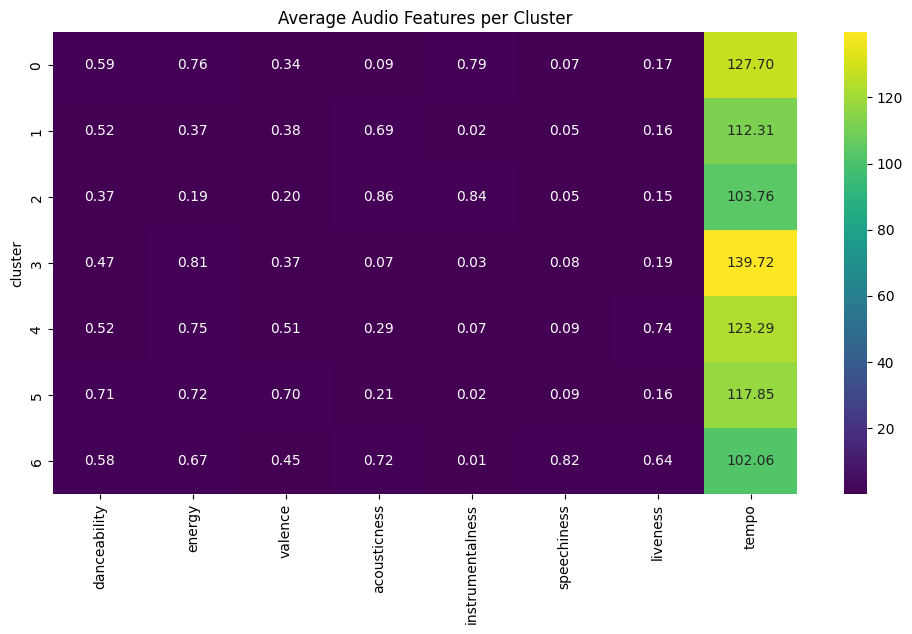

In [22]:
# HEATMAP
plt.figure(figsize=(12,6))
sns.heatmap(cluster_avg, annot=True, fmt=".2f", cmap="viridis")
plt.title("Average Audio Features per Cluster")
plt.show()

## # TOP ARTISTS PER CLUSTER

In [23]:
# Extract top artists
for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} Top Artists:")
    print(df[df["cluster"] == c]["artists"].value_counts().head(5))


Cluster 0 Top Artists:
artists
Boris Brejcha                  81
Robert Hood                    73
The Prophet                    57
Sarah, the Illstrumentalist    56
Napalm Death                   51
Name: count, dtype: int64

Cluster 1 Top Artists:
artists
Ella Fitzgerald    210
George Jones       209
Prateek Kuhad      174
Norah Jones        132
Hank Williams      125
Name: count, dtype: int64

Cluster 2 Top Artists:
artists
Yiruma                                    93
Germaine Franco                           91
Little Symphony                           90
Wolfgang Amadeus Mozart;Danielle Laval    84
Alphaxone                                 78
Name: count, dtype: int64

Cluster 3 Top Artists:
artists
Linkin Park              147
Red Hot Chili Peppers    100
OneRepublic               83
Rob Zombie                81
Scooter                   77
Name: count, dtype: int64

Cluster 4 Top Artists:
artists
Charlie Brown Jr.     65
Exaltasamba           62
Henrique & Juliano    50
Trazen

## #SUMMARY TABLE

In [24]:
# For report purpose only
summary_table = df.groupby("cluster")[["energy", "valence", "tempo"]].mean()
summary_table

,energy,valence,tempo
cluster,,,
0,0.757270,0.338454,127.702535
1,0.372103,0.376548,112.314661
2,0.189541,0.203960,103.762211
3,0.807849,0.371552,139.723268
4,0.748116,0.507470,123.289989
5,0.716016,0.695650,117.854693
6,0.669989,0.446394,102.057166
